In [ ]:
# %% [Cell 1] Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv("/content/amazon_review (1).csv")   # update path if needed in Colab
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
0,A3SBTW3WS4IQSN,B007WTAJTO,NaN,"[0, 0]",No issues.,4.0,Four Stars,1406073600,2014-07-23,138,0,0
1,A18K1ODH1I2MVB,B007WTAJTO,0mie,"[0, 0]","Purchased this for my device, it worked as adv...",5.0,MOAR SPACE!!!,1382659200,2013-10-25,409,0,0
2,A2FII3I2MBMUIA,B007WTAJTO,1K3,"[0, 0]",it works as expected. I should have sprung for...,4.0,nothing to really say....,1356220800,2012-12-23,715,0,0
3,A3H99DFEG68SR,B007WTAJTO,1m2,"[0, 0]",This think has worked out great.Had a diff. br...,5.0,Great buy at this price!!! *** UPDATE,1384992000,2013-11-21,382,0,0
4,A375ZM4U047O79,B007WTAJTO,2&amp;1/2Men,"[0, 0]","Bought it with Retail Packaging, arrived legit...",5.0,best deal around,1373673600,2013-07-13,513,0,0


In [ ]:
print("Rows, Columns:", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nData types:\n", df.dtypes)

Rows, Columns: (4915, 12)

Column names:
 ['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']

Data types:
 reviewerID         object
asin               object
reviewerName       object
helpful            object
reviewText         object
overall           float64
summary            object
unixReviewTime      int64
reviewTime         object
day_diff            int64
helpful_yes         int64
total_vote          int64
dtype: object


In [ ]:
print(df.columns.tolist())

['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']


In [ ]:
print(df.head())
print(df.tail())

       reviewerID        asin  reviewerName helpful  \
0  A3SBTW3WS4IQSN  B007WTAJTO           NaN  [0, 0]   
1  A18K1ODH1I2MVB  B007WTAJTO          0mie  [0, 0]   
2  A2FII3I2MBMUIA  B007WTAJTO           1K3  [0, 0]   
3   A3H99DFEG68SR  B007WTAJTO           1m2  [0, 0]   
4  A375ZM4U047O79  B007WTAJTO  2&amp;1/2Men  [0, 0]   

                                          reviewText  overall  \
0                                         No issues.      4.0   
1  Purchased this for my device, it worked as adv...      5.0   
2  it works as expected. I should have sprung for...      4.0   
3  This think has worked out great.Had a diff. br...      5.0   
4  Bought it with Retail Packaging, arrived legit...      5.0   

                                  summary  unixReviewTime  reviewTime  \
0                              Four Stars      1406073600  2014-07-23   
1                           MOAR SPACE!!!      1382659200  2013-10-25   
2               nothing to really say....      1356220800  

In [ ]:
df.describe(include='all')

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,day_diff,helpful_yes,total_vote
count,4915,4915,4914,4915,4914,4915.000000,4915,4.915000e+03,4915,4915.000000,4915.000000,4915.000000
unique,4915,1,4594,42,4912,NaN,3885,NaN,690,NaN,NaN,NaN
top,A8KGFTFQ86IBR,B007WTAJTO,Amazon Customer,"[0, 0]",Works fine my Virgin Mobile HTC EVO V. The pho...,NaN,Five Stars,NaN,2013-12-30,NaN,NaN,NaN
freq,1,4915,121,4360,2,NaN,46,NaN,26,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,4.587589,NaN,1.379465e+09,NaN,437.367040,1.311089,1.521465
std,NaN,NaN,NaN,NaN,NaN,0.996845,NaN,1.581857e+07,NaN,209.439871,41.619161,44.123095
min,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.339200e+09,NaN,1.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,1.365898e+09,NaN,281.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,1.381277e+09,NaN,431.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,1.392163e+09,NaN,601.000000,0.000000,0.000000


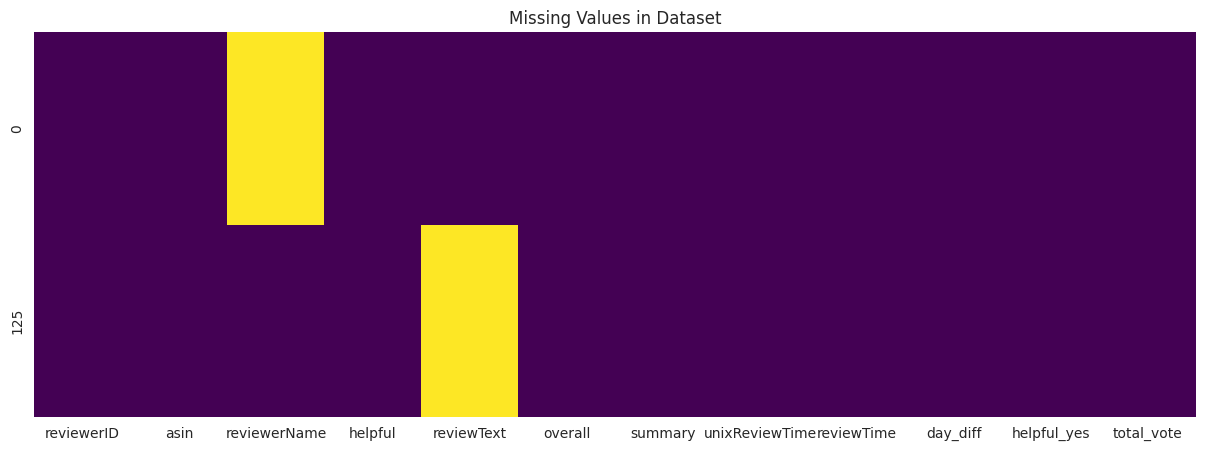

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_rows = df[df.isnull().any(axis=1)]

plt.figure(figsize=(15, 5))

sns.heatmap(
    missing_rows.isnull(),
    cbar=False,
    yticklabels=True,
    cmap="viridis"
)

plt.title("Missing Values in Dataset")
plt.show()

In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 2


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_percent': missing_pct})

,missing_count,missing_percent
reviewerID,0,0.00
asin,0,0.00
reviewerName,1,0.02
helpful,0,0.00
reviewText,1,0.02
overall,0,0.00
summary,0,0.00
unixReviewTime,0,0.00
reviewTime,0,0.00
day_diff,0,0.00


In [ ]:
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate reviewText values:", df['reviewText'].duplicated().sum())
print("Duplicate (reviewerID + reviewText) pairs:",
      df.duplicated(subset=['reviewerID', 'reviewText']).sum())

Fully duplicate rows: 0
Duplicate reviewText values: 2
Duplicate (reviewerID + reviewText) pairs: 0


In [ ]:
for col in ['reviewerID', 'asin', 'reviewerName', 'helpful', 'overall', 'summary', 'reviewTime']:
    print(f"{col}: {df[col].nunique()} unique values")

reviewerID: 4915 unique values
asin: 1 unique values
reviewerName: 4594 unique values
helpful: 42 unique values
overall: 5 unique values
summary: 3885 unique values
reviewTime: 690 unique values


In [ ]:
def check_helpful_match(row):
    try:
        h = ast.literal_eval(row['helpful'])
        return h[0] == row['helpful_yes'] and h[1] == row['total_vote']
    except Exception:
        return None

matches = df.apply(check_helpful_match, axis=1)
print("Rows where 'helpful' column matches helpful_yes/total_vote:", matches.sum(), "out of", len(df))

Rows where 'helpful' column matches helpful_yes/total_vote: 4915 out of 4915


In [ ]:
print(df['overall'].value_counts().sort_index())
print((df['overall'].value_counts(normalize=True).sort_index() * 100).round(2))

overall
1.0     244
2.0      80
3.0     142
4.0     527
5.0    3922
Name: count, dtype: int64
overall
1.0     4.96
2.0     1.63
3.0     2.89
4.0    10.72
5.0    79.80
Name: proportion, dtype: float64


/tmp/ipykernel_1539/385060117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='overall', data=df, palette='viridis', order=sorted(df['overall'].unique()))


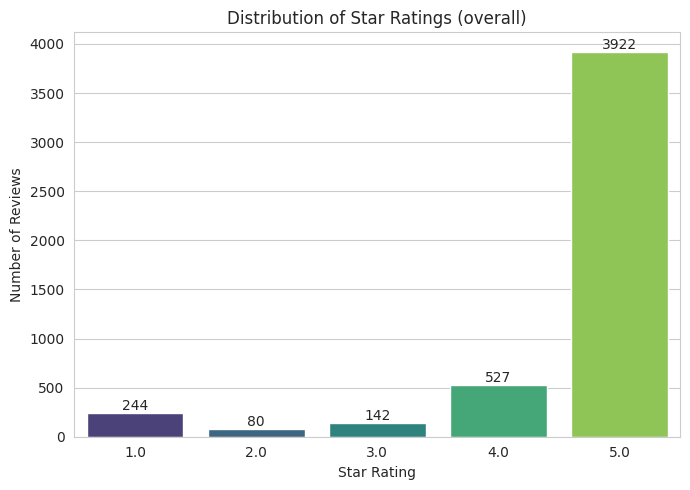

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='overall', data=df, palette='viridis', order=sorted(df['overall'].unique()))
plt.title("Distribution of Star Ratings (overall)")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
df['review_char_count'] = df['reviewText'].fillna('').apply(len)
df['review_word_count'] = df['reviewText'].fillna('').apply(lambda x: len(str(x).split()))
df['summary_word_count'] = df['summary'].fillna('').apply(lambda x: len(str(x).split()))

df[['review_char_count', 'review_word_count', 'summary_word_count']].describe()

,review_char_count,review_word_count,summary_word_count
count,4915.000000,4915.000000,4915.000000
mean,267.692981,50.442319,4.385148
std,328.853307,59.114860,2.987830
min,0.000000,0.000000,1.000000
25%,123.000000,23.000000,2.000000
50%,172.000000,33.000000,4.000000
75%,289.000000,55.000000,6.000000
max,8638.000000,1554.000000,30.000000


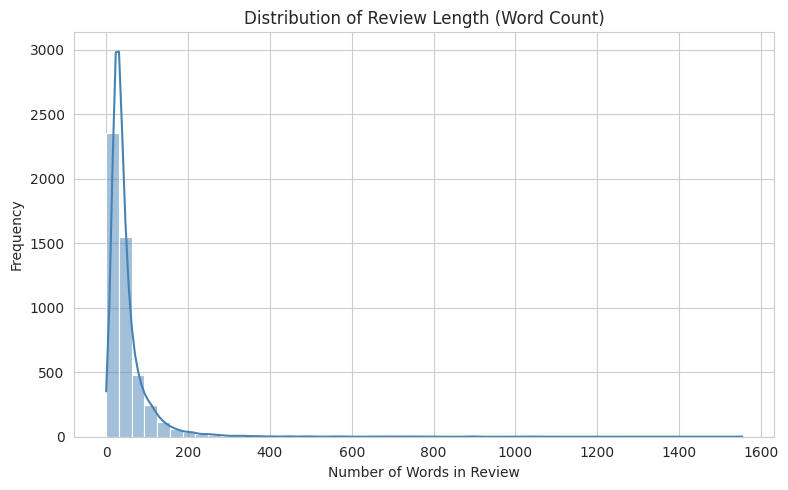

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['review_word_count'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Review Length (Word Count)")
plt.xlabel("Number of Words in Review")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

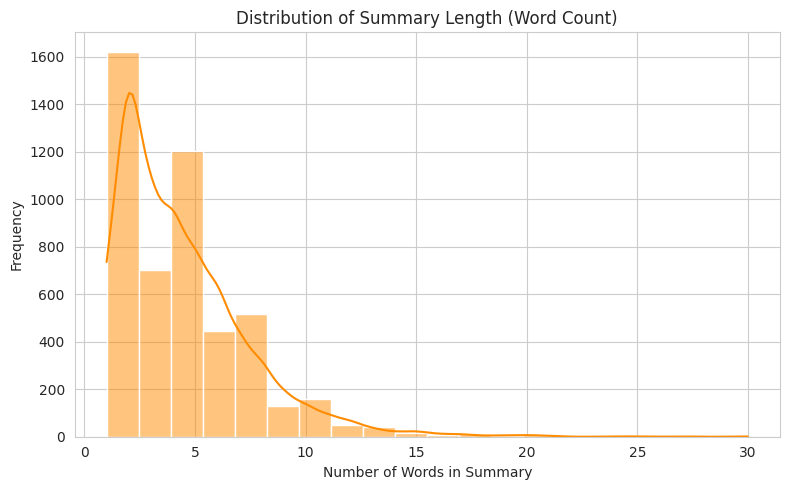

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['summary_word_count'], bins=20, kde=True, color='darkorange')
plt.title("Distribution of Summary Length (Word Count)")
plt.xlabel("Number of Words in Summary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1539/1457678912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='overall', y='review_word_count', data=df, palette='coolwarm')


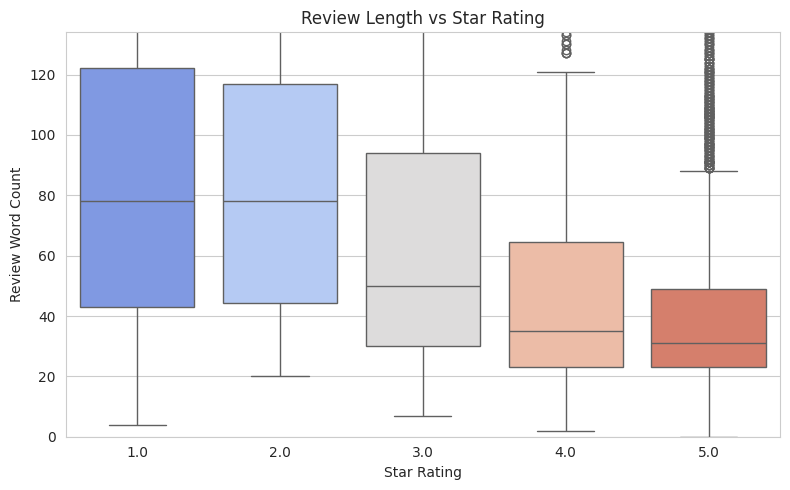

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='overall', y='review_word_count', data=df, palette='coolwarm')
plt.title("Review Length vs Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Review Word Count")
plt.ylim(0, df['review_word_count'].quantile(0.95))  # zoom in, exclude extreme outliers visually
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('overall')['review_word_count'].mean().round(2)

,review_word_count
overall,
1.0,103.86
2.0,114.48
3.0,73.25
4.0,56.21
5.0,44.21


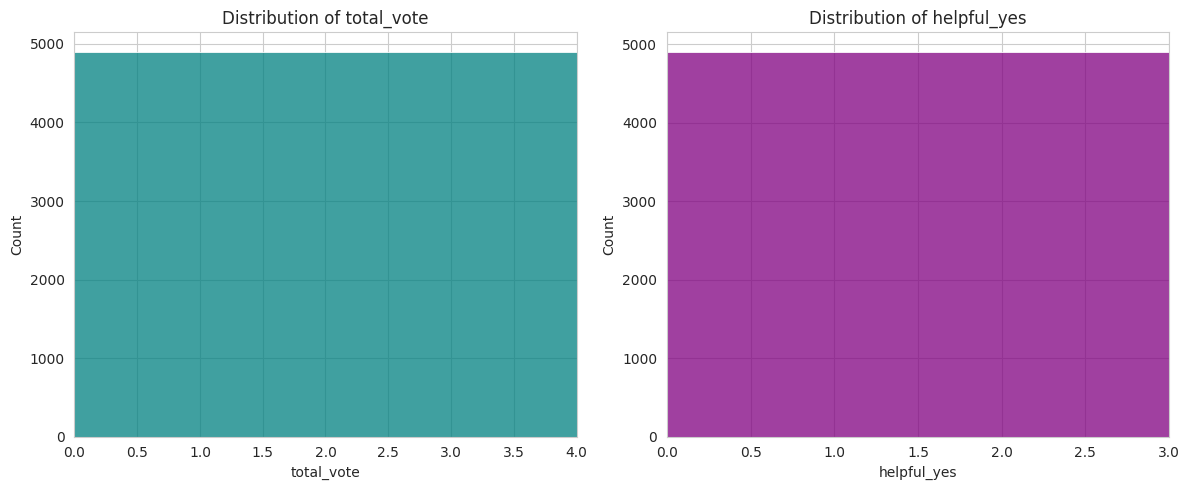

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['total_vote'], bins=50, ax=axes[0], color='teal')
axes[0].set_title("Distribution of total_vote")
axes[0].set_xlim(0, df['total_vote'].quantile(0.99))

sns.histplot(df['helpful_yes'], bins=50, ax=axes[1], color='purple')
axes[1].set_title("Distribution of helpful_yes")
axes[1].set_xlim(0, df['helpful_yes'].quantile(0.99))
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('overall')[['helpful_yes', 'total_vote']].mean().round(2)

,helpful_yes,total_vote
overall,,
1.0,8.97,10.40
2.0,0.24,0.54
3.0,0.35,0.54
4.0,0.21,0.61
5.0,1.04,1.15


/tmp/ipykernel_1539/2019621245.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_year', data=df, palette='crest')


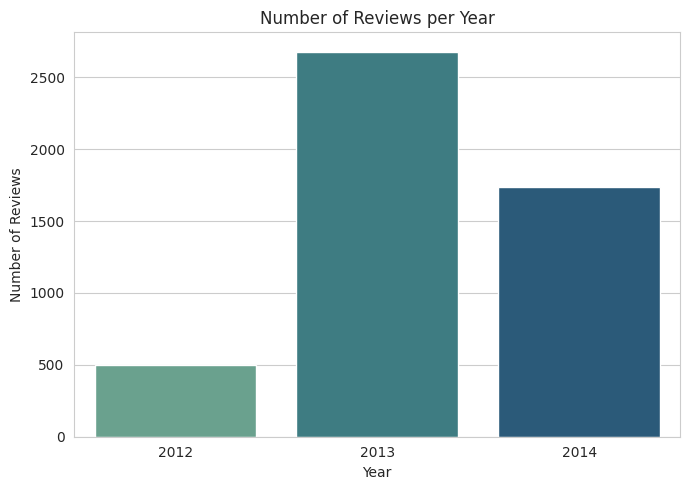

In [ ]:
df['reviewTime_parsed'] = pd.to_datetime(df['reviewTime'])
df['review_year'] = df['reviewTime_parsed'].dt.year

plt.figure(figsize=(7, 5))
sns.countplot(x='review_year', data=df, palette='crest')
plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1539/2566476436.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=words_df, palette='mako')


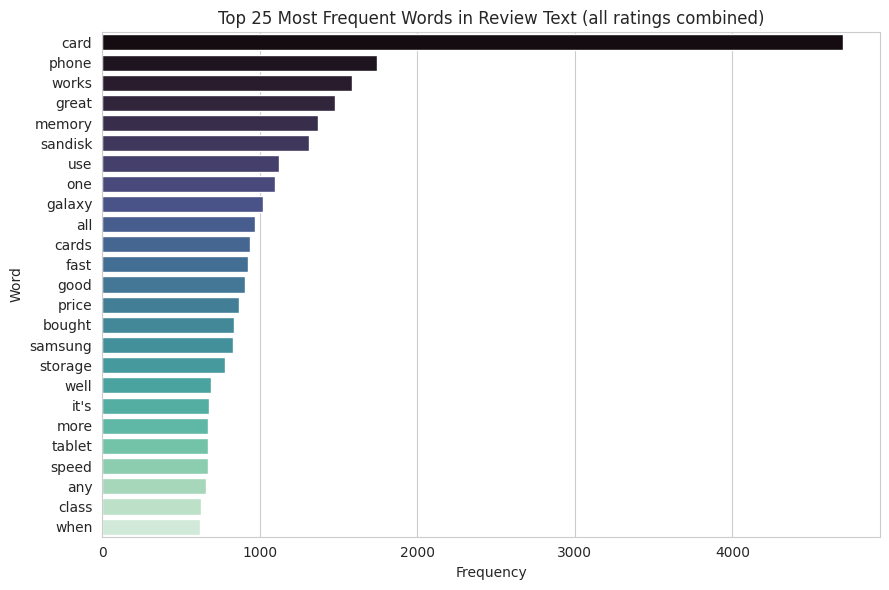

In [ ]:
from collections import Counter
import re

def get_words(text_series):
    words = []
    for t in text_series.fillna(''):
        tokens = re.findall(r"[a-zA-Z']+", str(t).lower())
        words.extend(tokens)
    return words

# Simple English stopword list (avoids needing internet / nltk download in Colab)
stopwords = set("""a an the this that these those is are was were be been being
i you he she it we they my your his her its our their me him them us
and or but if then so as of to in on at for with from by about into
have has had do does did not no nor can will would should could may might
just very s t re ve ll d m""".split())

all_words = get_words(df['reviewText'])
filtered_words = [w for w in all_words if w not in stopwords and len(w) > 2]
word_freq = Counter(filtered_words).most_common(25)

words_df = pd.DataFrame(word_freq, columns=['word', 'count'])
plt.figure(figsize=(9, 6))
sns.barplot(x='count', y='word', data=words_df, palette='mako')
plt.title("Top 25 Most Frequent Words in Review Text (all ratings combined)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1539/3101714171.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=high_freq, ax=axes[0], palette='Greens_r')
/tmp/ipykernel_1539/3101714171.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=low_freq, ax=axes[1], palette='Reds_r')


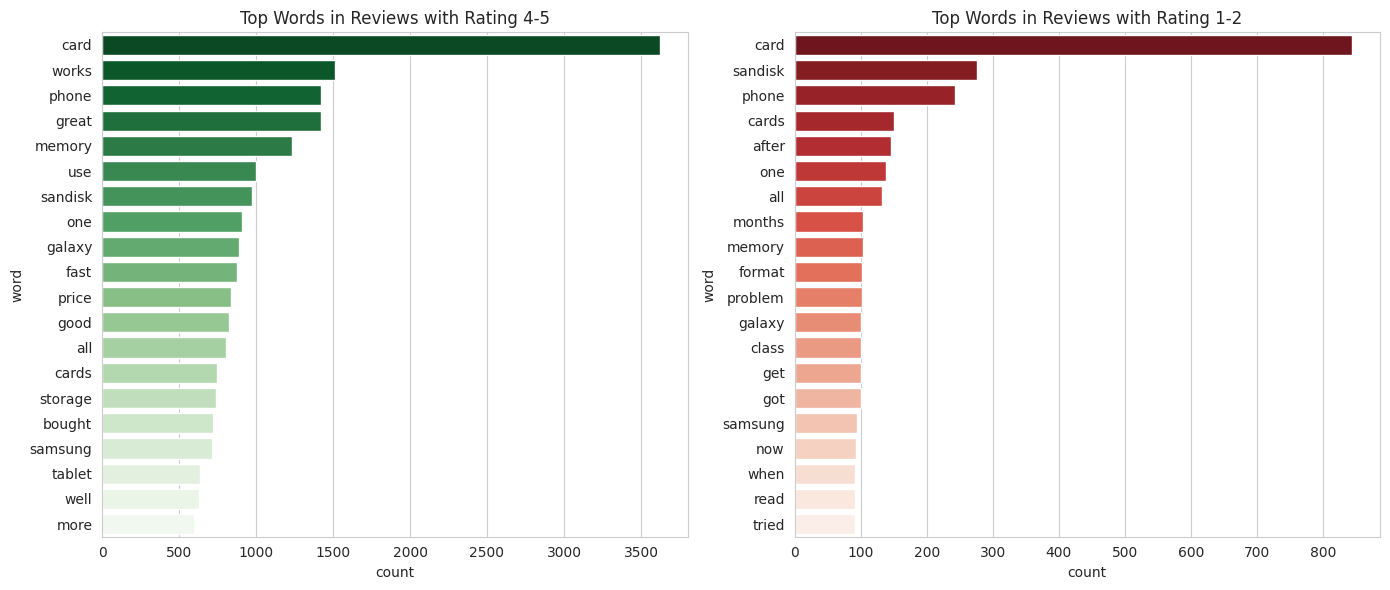

In [ ]:
high_rating_words = get_words(df.loc[df['overall'] >= 4, 'reviewText'])
low_rating_words  = get_words(df.loc[df['overall'] <= 2, 'reviewText'])

high_filtered = [w for w in high_rating_words if w not in stopwords and len(w) > 2]
low_filtered  = [w for w in low_rating_words  if w not in stopwords and len(w) > 2]

high_freq = pd.DataFrame(Counter(high_filtered).most_common(20), columns=['word', 'count'])
low_freq  = pd.DataFrame(Counter(low_filtered).most_common(20),  columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x='count', y='word', data=high_freq, ax=axes[0], palette='Greens_r')
axes[0].set_title("Top Words in Reviews with Rating 4-5")

sns.barplot(x='count', y='word', data=low_freq, ax=axes[1], palette='Reds_r')
axes[1].set_title("Top Words in Reviews with Rating 1-2")
plt.tight_layout()
plt.show()

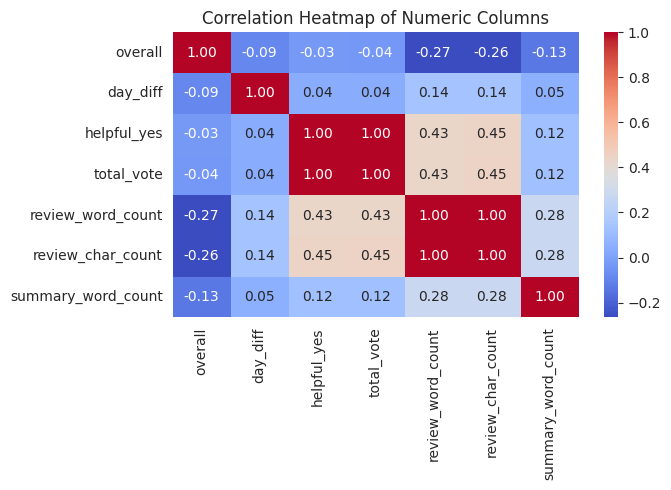

In [ ]:
plt.figure(figsize=(7, 5))
numeric_cols = ['overall', 'day_diff', 'helpful_yes', 'total_vote',
                 'review_word_count', 'review_char_count', 'summary_word_count']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Numeric Columns")
plt.tight_layout()
plt.show()

# Product Review Sentiment Analysis Using NLP and BERT

## Project Implementation

The exploratory data analysis (EDA) performed above provided an understanding of the dataset, its attributes, missing values, rating distribution, and sentiment distribution.

The next stage of the project focuses on building a machine learning based sentiment classification system. The system will use customer review text to classify product reviews into two sentiment categories:

- **Positive (1):** Ratings 4 and 5
- **Negative (0):** Ratings 1, 2 and 3

The implementation consists of data preparation, sentiment classification, model training, evaluation, and prediction on new reviews.

The project uses **Scikit-learn** for the traditional machine learning baseline and **BERT** for context-aware NLP-based sentiment classification.


## 1. Importing Required Libraries

The following libraries are used for data preparation, machine learning, evaluation, visualization, and BERT-based natural language processing.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Required libraries imported successfully.")

Required libraries imported successfully.


## 2. Data Preparation

The dataset is loaded and prepared for model development. The review text is used as the input feature, while the product rating is used to generate the sentiment labels.

In [ ]:
# Load the dataset
import pandas as pd

df = pd.read_csv("/content/amazon_review (1).csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (4915, 12)

Columns:
['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime', 'day_diff', 'helpful_yes', 'total_vote']


In [ ]:
# Create project dataset using review text and rating
project_data = df[["reviewText", "overall"]].copy()

# Remove missing review text
project_data = project_data.dropna(subset=["reviewText"])

# Remove blank review text
project_data = project_data[
    project_data["reviewText"].astype(str).str.strip() != ""
]

print("Dataset after removing missing/blank reviews:")
print(project_data.shape)

Dataset after removing missing/blank reviews:
(4914, 2)


## 3. Sentiment Label Creation

The original product rating is converted into a binary sentiment label.

- Ratings 4 and 5 are classified as Positive (1).
- Ratings 1, 2 and 3 are classified as Negative (0).

This sentiment label will be used as the target variable for model training.

In [ ]:
# Create binary sentiment labels
project_data["sentiment"] = np.where(
    project_data["overall"] >= 4,
    1,
    0
)

print("Sentiment labels created successfully.")

print("\nSentiment Distribution:")
print(project_data["sentiment"].value_counts())

print("\nLabel Meaning:")
print("0 = Negative")
print("1 = Positive")

Sentiment labels created successfully.

Sentiment Distribution:
sentiment
1    4448
0     466
Name: count, dtype: int64

Label Meaning:
0 = Negative
1 = Positive


## 4. Prepared Dataset

After handling missing review text and creating the sentiment labels, the dataset is ready for machine learning.

The review text is the input feature, while the sentiment label is the target variable.

In [ ]:
print("Final dataset shape:", project_data.shape)

display(
    project_data[["reviewText", "sentiment"]].head(10)
)

Final dataset shape: (4914, 3)


,reviewText,sentiment
0,No issues.,1
1,"Purchased this for my device, it worked as adv...",1
2,it works as expected. I should have sprung for...,1
3,This think has worked out great.Had a diff. br...,1
4,"Bought it with Retail Packaging, arrived legit...",1
5,It's mini storage. It doesn't do anything els...,1
6,I have it in my phone and it never skips a bea...,1
7,It's hard to believe how affordable digital ha...,1
8,Works in a HTC Rezound. Was running short of ...,1
9,"in my galaxy s4, super fast card, and am total...",1


## 5. Input Features and Target Variable

The dataset is divided into:

- **Input (X):** Customer review text
- **Target (y):** Sentiment label

The models will learn the relationship between the review text and its corresponding sentiment.

In [ ]:
X = project_data["reviewText"]
y = project_data["sentiment"]

print("Input samples:", len(X))
print("Target samples:", len(y))

Input samples: 4914
Target samples: 4914


## 6. Train-Test Split

The dataset is divided into training and testing sets using Scikit-learn's `train_test_split`.

The training set is used to train the models, while the testing set is used for evaluation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 3931
Testing samples: 983

Training class distribution:
sentiment
1    3558
0     373
Name: count, dtype: int64

Testing class distribution:
sentiment
1    890
0     93
Name: count, dtype: int64


# 7. TF-IDF + Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature matrix:", X_train_tfidf.shape)
print("Testing feature matrix:", X_test_tfidf.shape)

Training feature matrix: (3931, 5000)
Testing feature matrix: (983, 5000)


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


### Baseline Evaluation

In [ ]:
baseline_predictions = lr_model.predict(X_test_tfidf)

baseline_accuracy = accuracy_score(
    y_test, baseline_predictions
)

baseline_precision = precision_score(
    y_test, baseline_predictions, zero_division=0
)

baseline_recall = recall_score(
    y_test, baseline_predictions, zero_division=0
)

baseline_f1 = f1_score(
    y_test, baseline_predictions, zero_division=0
)

print("TF-IDF + Logistic Regression")
print("----------------------------")
print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-Score  : {baseline_f1:.4f}")

TF-IDF + Logistic Regression
----------------------------
Accuracy  : 0.9186
Precision : 0.9184
Recall    : 0.9989
F1-Score  : 0.9569


### Confusion Matrix

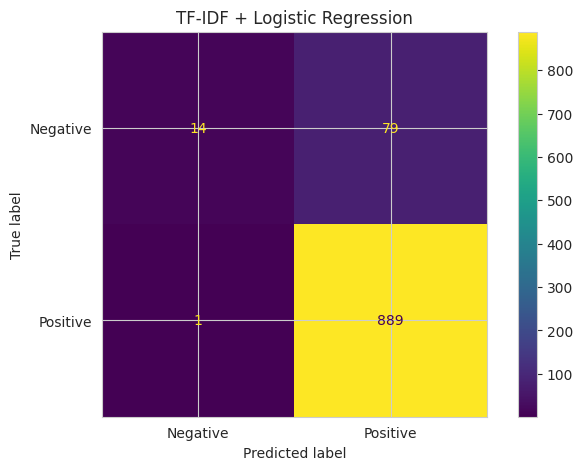

In [ ]:
cm_baseline = confusion_matrix(
    y_test,
    baseline_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("TF-IDF + Logistic Regression")
plt.show()

### Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.93      0.15      0.26        93
    Positive       0.92      1.00      0.96       890

    accuracy                           0.92       983
   macro avg       0.93      0.57      0.61       983
weighted avg       0.92      0.92      0.89       983



# 8. BERT Model

In [ ]:
!pip install -q transformers datasets accelerate

### BERT Setup

In [ ]:
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


### Prepare BERT Data

In [ ]:
train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 3931
})
Dataset({
    features: ['text', 'label'],
    num_rows: 983
})


### BERT Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3931 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

Tokenization completed.


### Load BERT

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT model loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded.


### Training Configuration

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

print("Training configuration ready.")

Training configuration ready.


### BERT Training

In [ ]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("BERT libraries loaded successfully.")
print("PyTorch version:", torch.__version__)

BERT libraries loaded successfully.
PyTorch version: 2.11.0+cpu


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test
)

print("Starting BERT training...")

trainer.train()

Starting BERT training...


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.198709


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.198709
2,0.204372,0.210803


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=984, training_loss=0.15554972392756763, metrics={'train_runtime': 10421.0157, 'train_samples_per_second': 0.754, 'train_steps_per_second': 0.094, 'total_flos': 517144779310080.0, 'train_loss': 0.15554972392756763, 'epoch': 2.0})

##Bert Evaluation

In [ ]:
bert_results = trainer.predict(tokenized_test)

bert_predictions = np.argmax(
    bert_results.predictions,
    axis=1
)

bert_accuracy = accuracy_score(
    y_test,
    bert_predictions
)

bert_precision = precision_score(
    y_test,
    bert_predictions,
    zero_division=0
)

bert_recall = recall_score(
    y_test,
    bert_predictions,
    zero_division=0
)

bert_f1 = f1_score(
    y_test,
    bert_predictions,
    zero_division=0
)

print("BERT Results")
print("------------")
print(f"Accuracy  : {bert_accuracy:.4f}")
print(f"Precision : {bert_precision:.4f}")
print(f"Recall    : {bert_recall:.4f}")
print(f"F1-Score : {bert_f1:.4f}")

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


BERT Results
------------
Accuracy  : 0.9440
Precision : 0.9533
Recall    : 0.9865
F1-Score : 0.9696


##Confusion Matrix

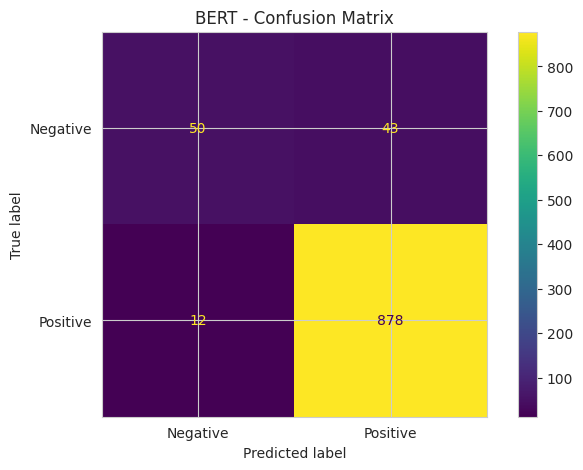

In [ ]:
cm_bert = confusion_matrix(
    y_test,
    bert_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("BERT - Confusion Matrix")
plt.show()

##Classification Report

In [48]:
print(
    classification_report(
        y_test,
        bert_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.81      0.54      0.65        93
    Positive       0.95      0.99      0.97       890

    accuracy                           0.94       983
   macro avg       0.88      0.76      0.81       983
weighted avg       0.94      0.94      0.94       983



#Model Comparison

##Comparison

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "BERT"
    ],
    "Accuracy": [
        baseline_accuracy,
        bert_accuracy
    ],
    "Precision": [
        baseline_precision,
        bert_precision
    ],
    "Recall": [
        baseline_recall,
        bert_recall
    ],
    "F1-Score": [
        baseline_f1,
        bert_f1
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + Logistic Regression,0.918616,0.918388,0.998876,0.956943
1,BERT,0.944049,0.953312,0.986517,0.969630


##Comparison Graph

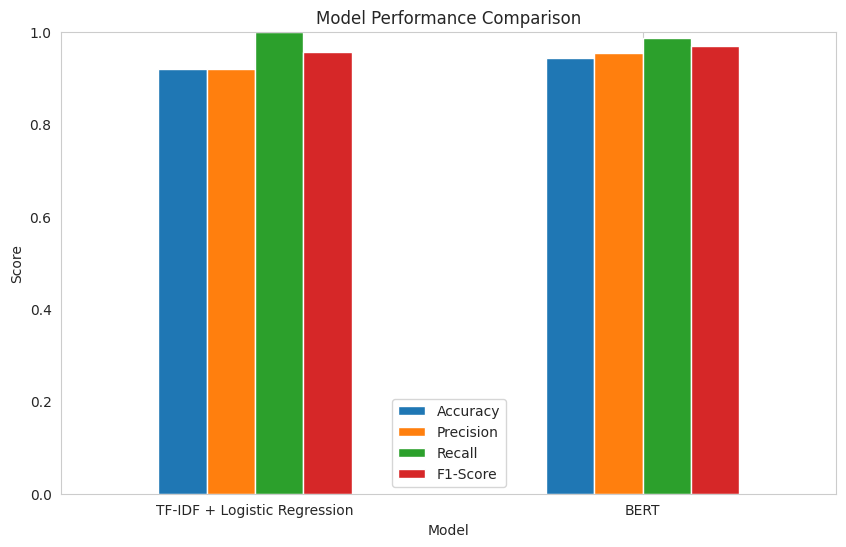

In [50]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##BERT Training Loss

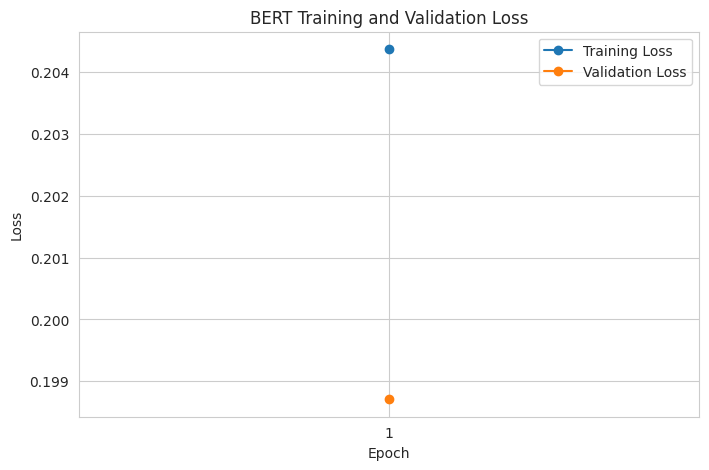

In [51]:
history = trainer.state.log_history

train_losses = {}
val_losses = {}

for x in history:
    if "loss" in x and "epoch" in x and "eval_loss" not in x:
        e = round(x["epoch"])
        train_losses[e] = x["loss"]

    if "eval_loss" in x and "epoch" in x:
        e = round(x["epoch"])
        val_losses[e] = x["eval_loss"]

epochs = sorted(
    set(train_losses) & set(val_losses)
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    [train_losses[e] for e in epochs],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    [val_losses[e] for e in epochs],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Training and Validation Loss")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

#Test on New Review

##Prediction Function

In [54]:
def predict_sentiment(review):

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    prediction = torch.argmax(
        probabilities,
        dim=1
    ).item()

    confidence = probabilities[0][prediction].item()

    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, confidence

##Try a Review

In [53]:
review = input("Enter a product review: ")

sentiment, confidence = predict_sentiment(review)

print("\nReview:", review)
print("Sentiment:", sentiment)
print(f"Confidence: {confidence:.2%}")

Enter a product review: This product is amazing and the quality is excellent. I really love it!

Review: This product is amazing and the quality is excellent. I really love it!
Sentiment: Positive
Confidence: 99.74%


#Save Model

In [55]:
model.save_pretrained("./bert_sentiment_model")
tokenizer.save_pretrained("./bert_sentiment_model")

print("BERT model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved successfully.


##Final Results

In [56]:
print("FINAL MODEL RESULTS")
print("===================")

print(f"\nTF-IDF + Logistic Regression")
print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-Score  : {baseline_f1:.4f}")

print(f"\nBERT")
print(f"Accuracy  : {bert_accuracy:.4f}")
print(f"Precision : {bert_precision:.4f}")
print(f"Recall    : {bert_recall:.4f}")
print(f"F1-Score  : {bert_f1:.4f}")

FINAL MODEL RESULTS

TF-IDF + Logistic Regression
Accuracy  : 0.9186
Precision : 0.9184
Recall    : 0.9989
F1-Score  : 0.9569

BERT
Accuracy  : 0.9440
Precision : 0.9533
Recall    : 0.9865
F1-Score  : 0.9696


In [57]:
import os

print("Saved model files:")

for file in os.listdir("./bert_sentiment_model"):
    print(file)

Saved model files:
tokenizer_config.json
model.safetensors
tokenizer.json
config.json


In [58]:
from google.colab import files
import shutil

shutil.make_archive(
    "bert_sentiment_model",
    "zip",
    "./bert_sentiment_model"
)

files.download("bert_sentiment_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>